In [88]:
# Imports
%matplotlib inline
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

In [133]:
# Read in the data file
dataFile = '2024_08_06_28mLaserData.mat'
data = scipy.io.loadmat(dataFile)


Text(0, 0.5, 'y (mm)')

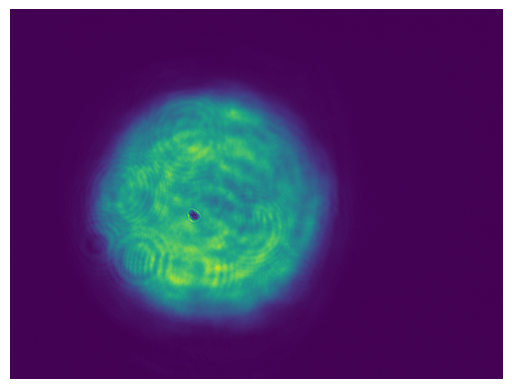

In [129]:
# Get an beam profile and plot it
img = data['MP2NF'][0][0][0]

# These cameras aren't spatial calibrated, but the MP2NF beam is roughly 40 mm wide to give you a rough sense of scale
rows,cols = img.shape
x = np.linspace(1,cols,cols)*0.000067 #This scale factor comes from a rough estimate
y = np.linspace(1,rows,rows)*0.000067 #This scale factor comes from a rough estimate

plt.figure()
plt.axis('off')
plt.imshow(img, extent=(1e3*x[0],1e3*x[-1],1e3*y[0],1e3*y[-1]))
plt.savefig("/Users/patilpar/Desktop/output.png", bbox_inches='tight', pad_inches = 0)
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')

In [130]:
img.dtype


dtype('uint8')

Text(0, 0.5, 'Spectral Intensity (Arb.)')

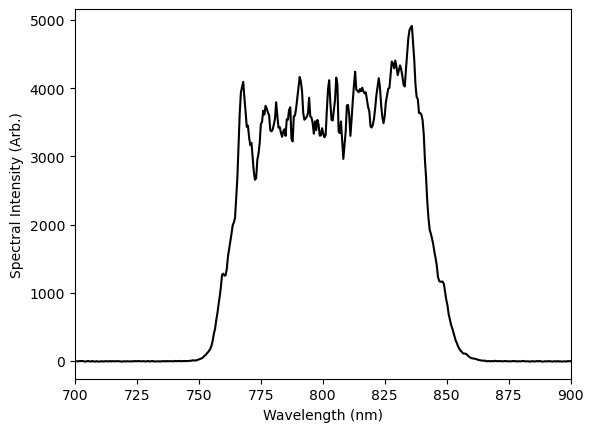

In [94]:
# Get spectrum and plot it
specData = data['spec_MPA2'][0,0][0]
wl = specData[:,0]
specInten = specData[:,1] - specData[0,1] # this minus here is a sneaky background subtraction

plt.figure()
plt.plot(wl,specInten,c=(0,0,0))
plt.xlim(700,900)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Spectral Intensity (Arb.)')


In [108]:
omega = 2*np.pi*3e8/(wl*1e-9)
omega_new = np.linspace(np.min(omega),np.max(omega),len(omega))
spectalIntenOmega = np.interp(omega_new, omega[::-1], specInten)

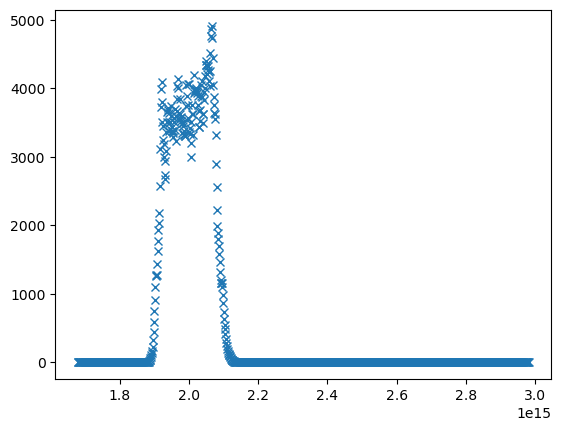

In [114]:
plt.figure()
plt.plot(omega_new,spectalIntenOmega,'x')

In [97]:
spectalIntenOmega[spectalIntenOmega<0] = 0
tempAmp = np.fft.ifftshift(np.fft.fft(np.fft.fftshift(np.sqrt((spectalIntenOmega)))))
tempInten = np.abs(tempAmp)**2

#timeAxis

In [115]:
tempInten

array([32.37931523, 10.61583196,  2.63742894, ...,  4.6955058 ,
        2.63742894, 10.61583196])

(450.0, 600.0)

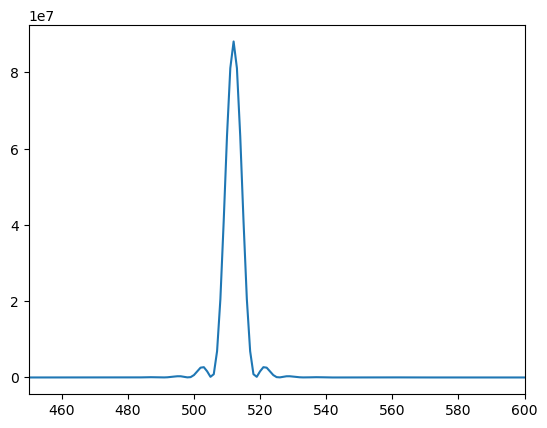

In [99]:
plt.figure()
plt.plot(tempInten)
plt.xlim(450,600)

In [100]:
from lasy.profiles.longitudinal.longitudinal_profile_from_data import LongitudinalProfileFromData

In [101]:
wl

array([ 632.1684 ,  632.6343 ,  633.10016, ..., 1121.898  , 1122.3915 ,
       1122.885  ], dtype=float32)

In [102]:
data = {}
data["datatype"] = "spectral"
data['axis'] = wl*1e-9
specInten[specInten<0] = 0
data['intensity'] = specInten
data["dt"] = .1e-15 # required timestep for the profile
lo = -50e-15
hi = 50e-15

prof = LongitudinalProfileFromData(data,lo,hi)

In [119]:
t = np.linspace(lo,hi,201)
temporalField = prof.evaluate(t)

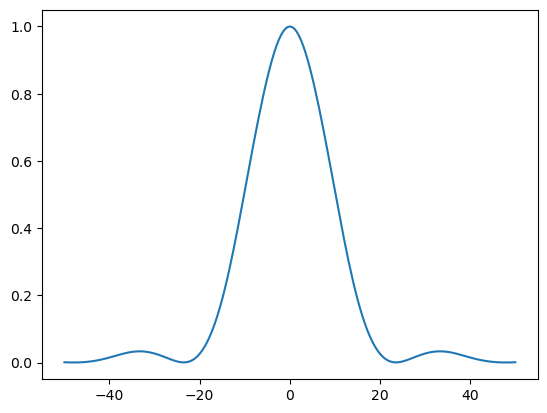

In [104]:
plt.figure()
plt.plot(t*1e15,np.abs(temporalField)**2)

In [105]:
def FWHM(t,inten):
    maxInten = np.max(inten)
    halfMax = maxInten/2
    idx = np.where(inten > halfMax)[0]
    return t[idx[-1]] - t[idx[0]]   
FWHM(t,np.abs(temporalField)**2)*1e15

20.000000000000004